In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Paths
CSV_DIR = "csv/day"
PLOT_DIR = "plots"
SUMMARY_DIR = ""
os.makedirs(PLOT_DIR, exist_ok=True)

# Month mapping and days
month_map = {
    "1": "jan", "2": "feb", "3": "mar", "4": "apr",
    "5": "may", "6": "jun", "7": "jul", "8": "aug",
    "9": "sep", "10": "oct", "11": "nov", "12": "dec"
}
month_days = {
    "jan": 31, "feb": 28, "mar": 31, "apr": 30,
    "may": 31, "jun": 30, "jul": 31, "aug": 31,
    "sep": 30, "oct": 31, "nov": 30, "dec": 31
}

# Summary data holders
classical_summary = {}
blockchain_summary = {}

# === Process each CSV ===
def process_csv(file_path, system_type, month_num):
    df = pd.read_csv(file_path)
    x_label = "Tick" if "Tick" in df.columns else "Day"
    node_columns = df.columns.drop(x_label)

    # Get month name and seconds in month
    month_name = month_map[month_num]
    seconds_in_month = month_days[month_name] * 24 * 60 * 60

    # Calculate average power across nodes per tick
    avg_power_per_tick = df[node_columns].mean(axis=1)
    avg_power_all_nodes = avg_power_per_tick.mean()

    # Compute total kWh over all nodes and ticks
    total_energy_kWh = df[node_columns].mean().mean() * seconds_in_month * len(node_columns) / 3600

    # Plot
    plt.figure(figsize=(12, 6))
    node_cumulative_kWh = {}

    for node in node_columns:
        avg_node_w = df[node].mean()
        cum_node_kWh = avg_node_w * seconds_in_month / 3600
        node_cumulative_kWh[node] = cum_node_kWh

        label = f"{node} (avg={avg_node_w:.4f} Ws, ∑={cum_node_kWh:.4f} kWh)"
        plt.plot(df[x_label], df[node], alpha=0.4, linewidth=1, label=label)

    avg_kWh_per_node = total_energy_kWh / len(node_columns)
    avg_label = f"Avg of Nodes (avg={avg_power_all_nodes:.2f} W, ∑/Node={avg_kWh_per_node:.6f} kWh)"
    plt.plot(df[x_label], avg_power_per_tick, color='black', linewidth=2, label=avg_label)
    plt.axhline(y=avg_power_all_nodes, color='red', linestyle='--')

    plt.title(
        f"Energy Consumption - {system_type.capitalize()} Month {month_num} "
        f"(Total={total_energy_kWh:.4f} kWh, Avg/Node={avg_kWh_per_node:.4f} kWh)"
    )
    plt.xlabel("Second")
    plt.ylabel("Power (Ws)")
    plt.grid(True)
    plt.legend(fontsize="small", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    plot_file = os.path.join(PLOT_DIR, f"{system_type}_month{month_num}_energy.png")
    plt.savefig(plot_file, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved plot: {plot_file}")

    # Save summary for later
    summary = classical_summary if system_type == "classical" else blockchain_summary
    for node, cum_kWh in node_cumulative_kWh.items():
        if node not in summary:
            summary[node] = {}
        summary[node][month_name] = f"{cum_kWh:.4f}"

# === Save summary as kWh table ===
def save_summary_csv(summary_dict, filename):
    df = pd.DataFrame(summary_dict).T
    df.insert(0, "Node", df.index)
    df = df.reindex(columns=["Node"] + [month_map[str(i)] for i in range(1, 13)])
    out_path = os.path.join(SUMMARY_DIR, filename)
    df.to_csv(out_path, index=False)
    print(f"📊 Saved summary CSV: {out_path}")
    return out_path

# === Process all CSVs ===
for file in sorted(os.listdir(CSV_DIR)):
    if file.endswith(".csv"):
        parts = file.replace(".csv", "").split("_")
        if len(parts) != 3:
            continue
        system_type, month_str, _ = parts
        if system_type not in ["classical", "blockchain"]:
            continue
        month_num = month_str.replace("month", "")
        process_csv(os.path.join(CSV_DIR, file), system_type, month_num)

# === Save and plot summary ===
classical_path = save_summary_csv(classical_summary, "classical23.csv")
blockchain_path = save_summary_csv(blockchain_summary, "blockchain23.csv")


✅ Saved plot: plots/blockchain_month10_energy.png
✅ Saved plot: plots/blockchain_month11_energy.png
✅ Saved plot: plots/blockchain_month12_energy.png
✅ Saved plot: plots/blockchain_month1_energy.png
✅ Saved plot: plots/blockchain_month2_energy.png
✅ Saved plot: plots/blockchain_month3_energy.png
✅ Saved plot: plots/blockchain_month4_energy.png
✅ Saved plot: plots/blockchain_month5_energy.png
✅ Saved plot: plots/blockchain_month6_energy.png
✅ Saved plot: plots/blockchain_month7_energy.png
✅ Saved plot: plots/blockchain_month8_energy.png
✅ Saved plot: plots/blockchain_month9_energy.png
✅ Saved plot: plots/classical_month10_energy.png
✅ Saved plot: plots/classical_month11_energy.png
✅ Saved plot: plots/classical_month12_energy.png
✅ Saved plot: plots/classical_month1_energy.png
✅ Saved plot: plots/classical_month2_energy.png
✅ Saved plot: plots/classical_month3_energy.png
✅ Saved plot: plots/classical_month4_energy.png
✅ Saved plot: plots/classical_month5_energy.png
✅ Saved plot: plots/cl

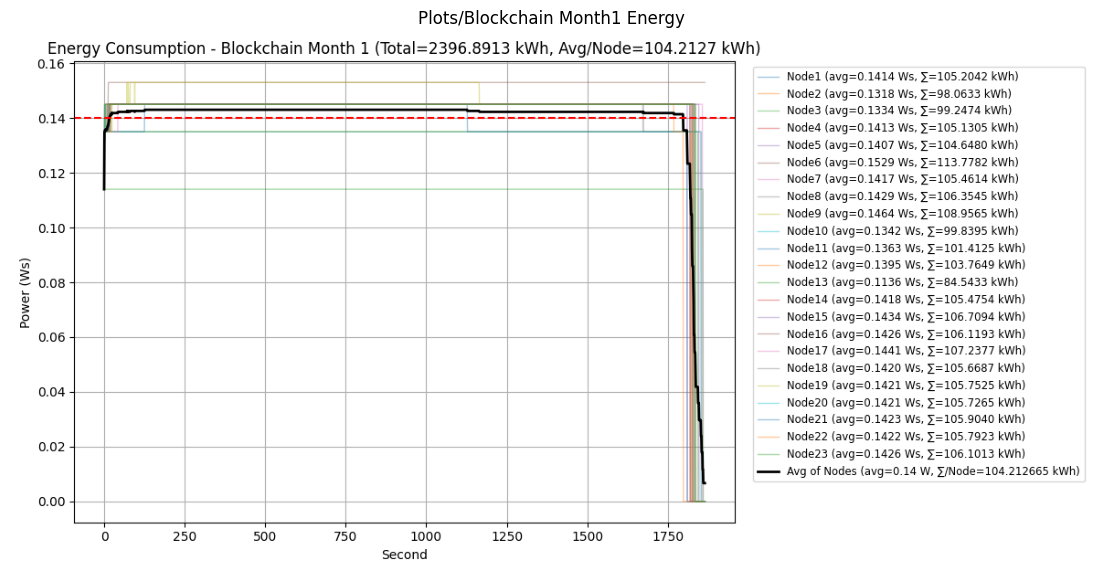

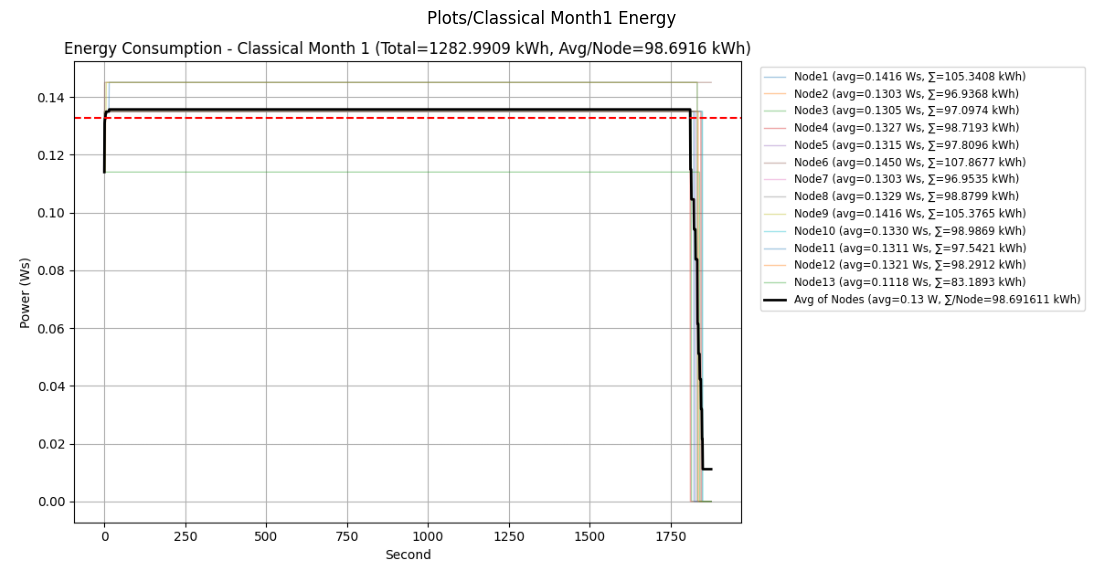

In [120]:
for name in ["plots/blockchain_month1_energy.png", "plots/classical_month1_energy.png"]:
    path = f"{name}"
    img = plt.imread(path)
    plt.figure(figsize=(14, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title(name.replace("_", " ").replace(".png", "").title())
    plt.show()

In [67]:
# def plot_summary_energy_kW(summary_csv, system_type, save_path="plots/summary"):
#     os.makedirs(save_path, exist_ok=True)

#     # Load and prep
#     df = pd.read_csv(summary_csv)
#     df.set_index("Node", inplace=True)

#     month_days = {
#         "jan": 31, "feb": 28, "mar": 31, "apr": 30,
#         "may": 31, "jun": 30, "jul": 31, "aug": 31,
#         "sep": 30, "oct": 31, "nov": 30, "dec": 31
#     }
#     month_labels = list(month_days.keys())

#     # Only select expected months
#     df = df[month_labels].apply(pd.to_numeric, errors="coerce")

#     # Convert kWh → kW by multiplying with total hours in each month
#     df_kW = df.copy()
#     for month in month_labels:
#         hours = month_days[month] * 24
#         df_kW[month] = df[month] * hours

#     # Plotting
#     plt.figure(figsize=(14, 7))
#     label_info = []

#     for node in df_kW.index:
#         plt.plot(month_labels, df_kW.loc[node], label=node, alpha=0.4)
#         avg_kWh = df.loc[node].mean()
#         total_kW = df_kW.loc[node].sum()
#         label_info.append(f"{node} (avg={avg_kWh:.2f} kWh, ∑={total_kW:.2f} kW)")

#     # Average line across all nodes
#     monthly_avg_kW = df_kW.mean(axis=0)
#     yearly_total_kW = df_kW.sum().sum()
#     avg_total_kWh = df.mean().mean()

#     avg_label = f"Avg Line (avg={avg_total_kWh:.2f} kWh, ∑={yearly_total_kW:.2f} kW)"
#     plt.plot(month_labels, monthly_avg_kW, color='black', linewidth=2, label=avg_label)

#     cumulative_kWh = df.sum().sum()
#     plt.title(f"Monthly Total Energy Summary - {system_type.capitalize()} (∑={yearly_total_kW:.2f} kW, {cumulative_kWh:.2f} kWh)")
#     plt.xlabel("Month")
#     plt.ylabel("Total Energy Consumption (kW)")  # <-- correct unit for Y-axis
#     plt.grid(True)
#     plt.legend(label_info + [avg_label], fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
#     plt.tight_layout()

#     # Save and show
#     plot_file = os.path.join(save_path, f"{system_type}_summary_energy_kW.png")
#     plt.savefig(plot_file, bbox_inches="tight")
#     plt.show()

#     print(f"📊 Energy summary plot saved to: {plot_file}")

#     # Save cumulative kW of each month
#     monthly_cumulative_kW = df_kW.sum(axis=0)  # Series: index=months, value=sum(kW)
#     monthly_cumulative_kW_df = monthly_cumulative_kW.to_frame(name="Total_kW")
#     monthly_cumulative_kW_df.index.name = "Month"
    
#     # Save to CSV
#     cumulative_kW_csv_path = os.path.join(save_path, f"{system_type}_monthly_total_energy_kW.csv")
#     monthly_cumulative_kW_df.to_csv(cumulative_kW_csv_path)
    
#     print(f"📄 Monthly cumulative energy in kW saved to: {cumulative_kW_csv_path}")


In [21]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import os

# def plot_summary_energy_kWh(summary_csv, system_type, save_path="plots/summary"):
#     os.makedirs(save_path, exist_ok=True)

#     # Load and clean
#     df = pd.read_csv(summary_csv)
#     df.set_index("Node", inplace=True)

#     # Define month columns (should be 12 months)
#     month_labels = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
#                     'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

#     # Ensure valid numeric values
#     df = df[month_labels].apply(pd.to_numeric, errors="coerce")

#     # Compute per-node stats
#     node_total_kWh = df.sum(axis=1)                      # Total yearly energy per node
#     node_avg_kWh_per_month = df.mean(axis=1)             # Avg monthly kWh per node
#     yearly_total_kWh = node_total_kWh.sum()              # Total across all nodes
#     monthly_avg_kWh = df.mean(axis=0)                    # Monthly average line across nodes
#     overall_avg_kWh_per_month = monthly_avg_kWh.mean()   # Avg of monthly averages
#     total_of_monthly_avg_line = monthly_avg_kWh.sum()    # Sum of the average line

#     # Plot each node's monthly kWh as a line
#     plt.figure(figsize=(14, 7))
#     label_info = []

#     for node in df.index:
#         plt.plot(month_labels, df.loc[node], alpha=0.4)
#         label_info.append(
#             f"{node}: Total = {node_total_kWh[node]:.2f} kWh | Avg/Month = {node_avg_kWh_per_month[node]:.2f} kWh"
#         )

#     # Add average monthly line with combined label
#     avg_label = f"Average: Total = {total_of_monthly_avg_line:.2f} kWh | Avg/Month = {node_avg_kWh_per_month[node]:.2f} kWh"
#     plt.plot(month_labels, monthly_avg_kWh, color='black', linewidth=2, label=avg_label)

#     # Plot title & labels
#     plt.title(f"Monthly Energy Usage - {system_type.capitalize()} (Cumulative = {yearly_total_kWh:,.2f} kWh)")
#     plt.xlabel("Month")
#     plt.ylabel("Energy Consumption (kWh)")
#     plt.grid(True)
#     plt.legend(label_info + [avg_label], fontsize="small", bbox_to_anchor=(1.02, 1), loc='upper left')
#     plt.tight_layout()

#     # Save plot
#     plot_file = os.path.join(save_path, f"{system_type}_monthly_energy_kWh_lines.png")
#     plt.savefig(plot_file, bbox_inches="tight")
#     plt.show()
#     print(f"📊 Monthly line plot saved to: {plot_file}")

#     # Save summary CSV
#     node_summary_df = pd.DataFrame({
#         "Total_Year_kWh": node_total_kWh,
#         "Average_kWh_per_Month": node_avg_kWh_per_month
#     })
#     node_summary_csv_path = os.path.join(save_path, f"{system_type}_node_summary_energy_kWh.csv")
#     node_summary_df.to_csv(node_summary_csv_path)
#     print(f"📄 Per-node total and average energy saved to: {node_summary_csv_path}")


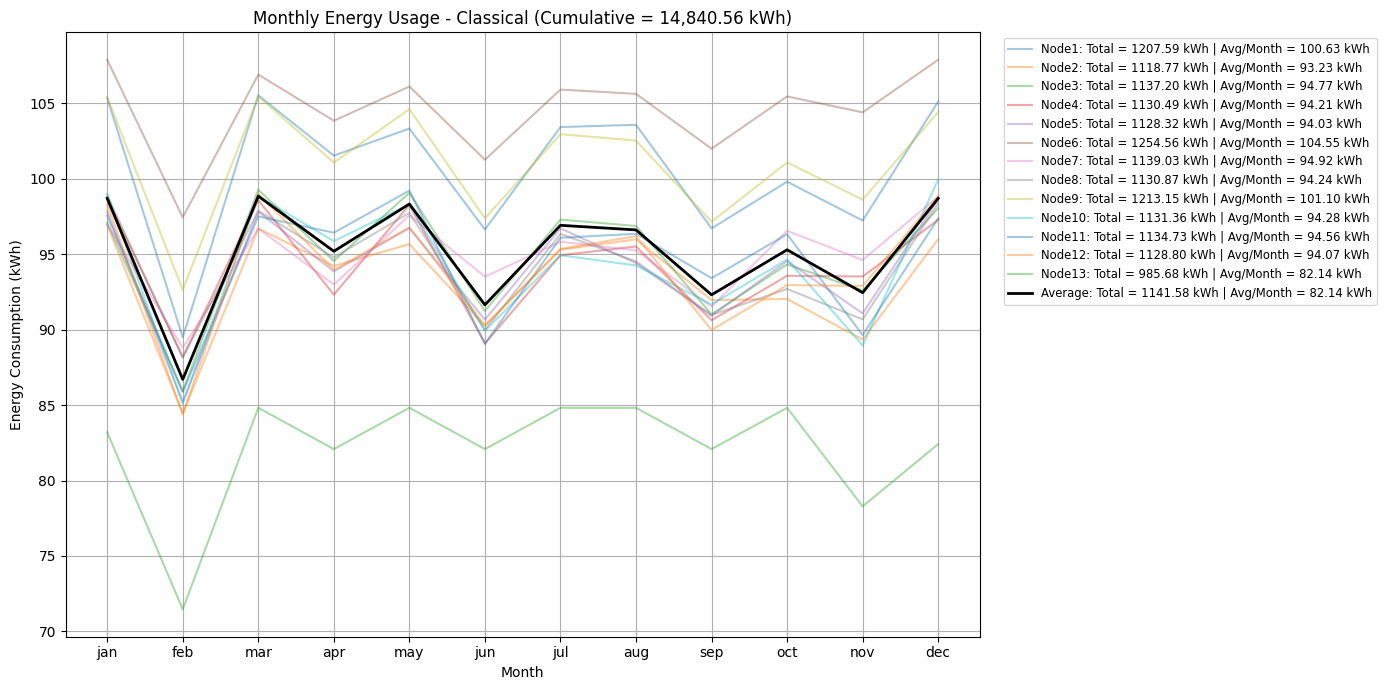

📊 Monthly line plot saved to: plots/summary/classical_monthly_energy_kWh_lines.png
📄 Per-node total and average energy saved to: plots/summary/classical_node_summary_energy_kWh.csv


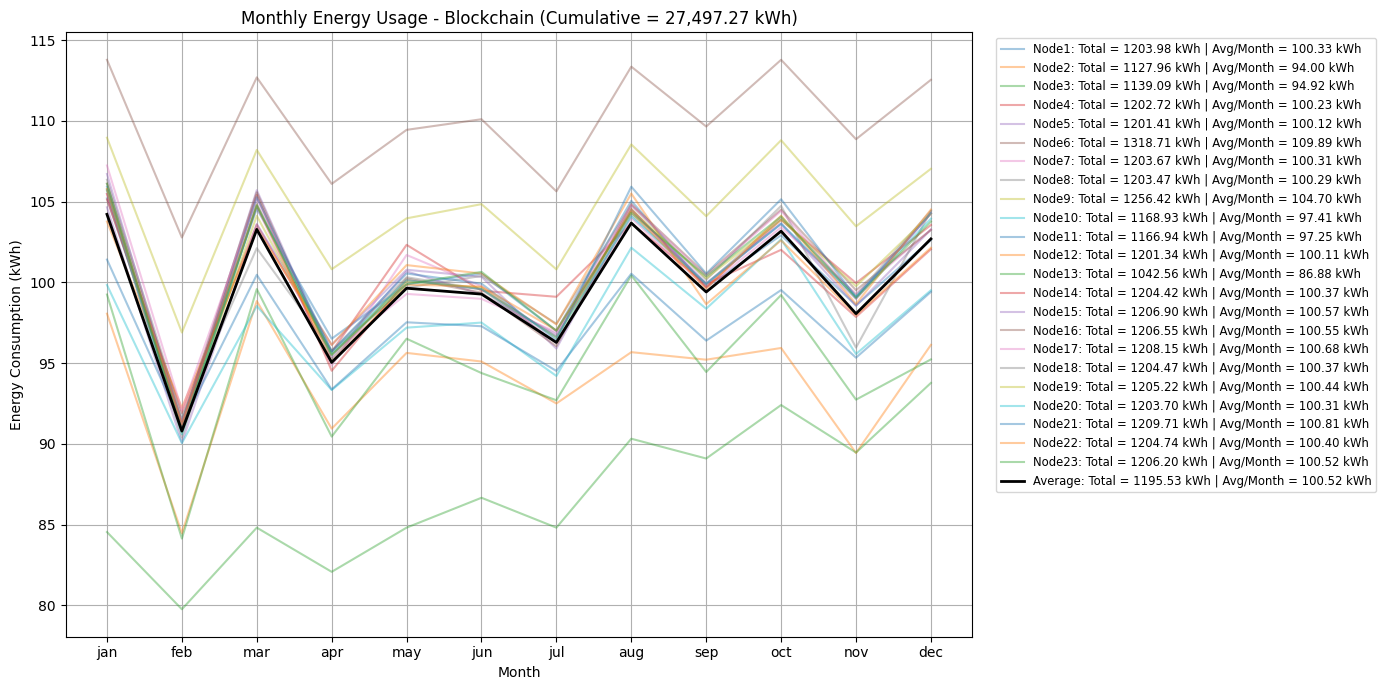

📊 Monthly line plot saved to: plots/summary/blockchain_monthly_energy_kWh_lines.png
📄 Per-node total and average energy saved to: plots/summary/blockchain_node_summary_energy_kWh.csv


In [22]:
plot_summary_energy_kWh(classical_path, "classical")
plot_summary_energy_kWh(blockchain_path, "blockchain")

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_summary_energy_kWh(summary_csv, system_type, save_path="plots/summary"):
    os.makedirs(save_path, exist_ok=True)

    # Load and clean
    df = pd.read_csv(summary_csv)
    df.set_index("Node", inplace=True)

    # Define month columns
    month_labels = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                    'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # Ensure valid numeric values
    df = df[month_labels].apply(pd.to_numeric, errors="coerce")

    # Compute per-node and system-wide totals
    node_total_kWh = df.sum(axis=1)
    yearly_total_kWh = node_total_kWh.sum()
    node_avg_kWh_per_month = df.mean(axis=1)
    monthly_avg_kWh = df.mean(axis=0)
    overall_avg_kWh_per_month = monthly_avg_kWh.mean()
    total_of_monthly_avg_line = monthly_avg_kWh.sum()

    # Plot each node's energy line
    plt.figure(figsize=(14, 7))
    label_info = []

    for node in df.index:
        plt.plot(month_labels, df.loc[node], alpha=0.4)
        label_info.append(
            f"{node}: Total = {node_total_kWh[node]:.2f} kWh | Avg/Month = {node_avg_kWh_per_month[node]:.2f} kWh"
        )

    # Average line
    avg_label = f"Average: Total = {total_of_monthly_avg_line:.2f} kWh | Avg/Month = {overall_avg_kWh_per_month:.2f} kWh"
    plt.plot(month_labels, monthly_avg_kWh, color='black', linewidth=2, label=avg_label)

    # Title & layout
    plt.title(f"Monthly Energy Usage - {system_type.capitalize()} (Cumulative = {yearly_total_kWh:,.2f} kWh)")
    plt.xlabel("Month")
    plt.ylabel("Energy Consumption (kWh)")
    plt.grid(True)
    plt.legend(label_info + [avg_label], fontsize="small", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()

    # Save plot
    plot_file = os.path.join(save_path, f"{system_type}_monthly_energy_kWh_lines.png")
    plt.savefig(plot_file, bbox_inches="tight")
    plt.show()
    print(f"📊 Monthly line plot saved to: {plot_file}")
    
    # ✅ Save total yearly energy per node
    cumulative_csv_path = os.path.join(save_path, f"{system_type}_total_year_energy_kWh.csv")
    node_total_kWh.to_frame(name="Total_Year_kWh").to_csv(cumulative_csv_path)
    print(f"📄 Saved cumulative energy CSV: {cumulative_csv_path}")
    
    # ✅ Save total energy per month across all nodes
    monthly_total_kWh = df.sum(axis=0)  # Series: months
    monthly_total_kWh_df = monthly_total_kWh.to_frame(name="Total_kWh")
    monthly_total_kWh_df.index.name = "Month"
    monthly_total_kWh_df.loc["Yearly_Total"] = yearly_total_kWh
    
    monthly_csv_path = os.path.join(save_path, f"{system_type}_monthly_total_energy_kWh.csv")
    monthly_total_kWh_df.to_csv(monthly_csv_path)
    print(f"📄 Saved monthly total energy CSV: {monthly_csv_path}")



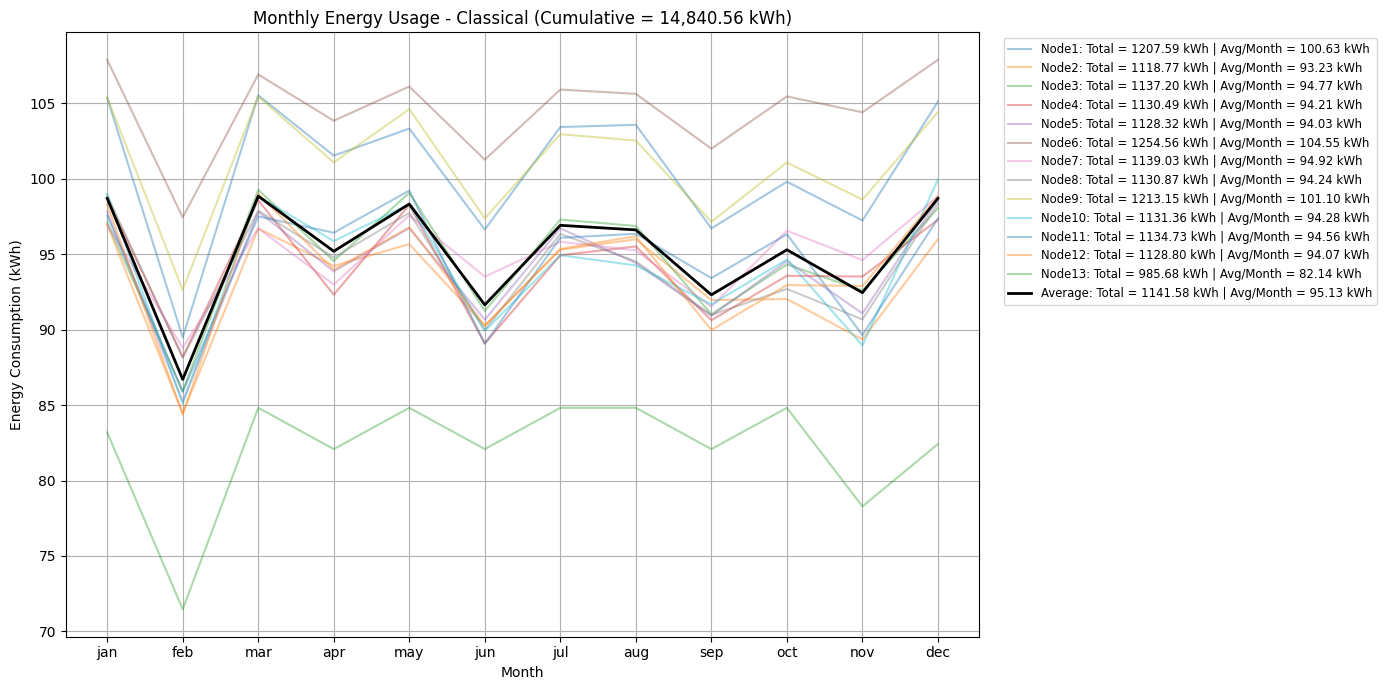

📊 Monthly line plot saved to: plots/summary/classical_monthly_energy_kWh_lines.png
📄 Saved cumulative energy CSV: plots/summary/classical_total_year_energy_kWh.csv
📄 Saved monthly total energy CSV: plots/summary/classical_monthly_total_energy_kWh.csv


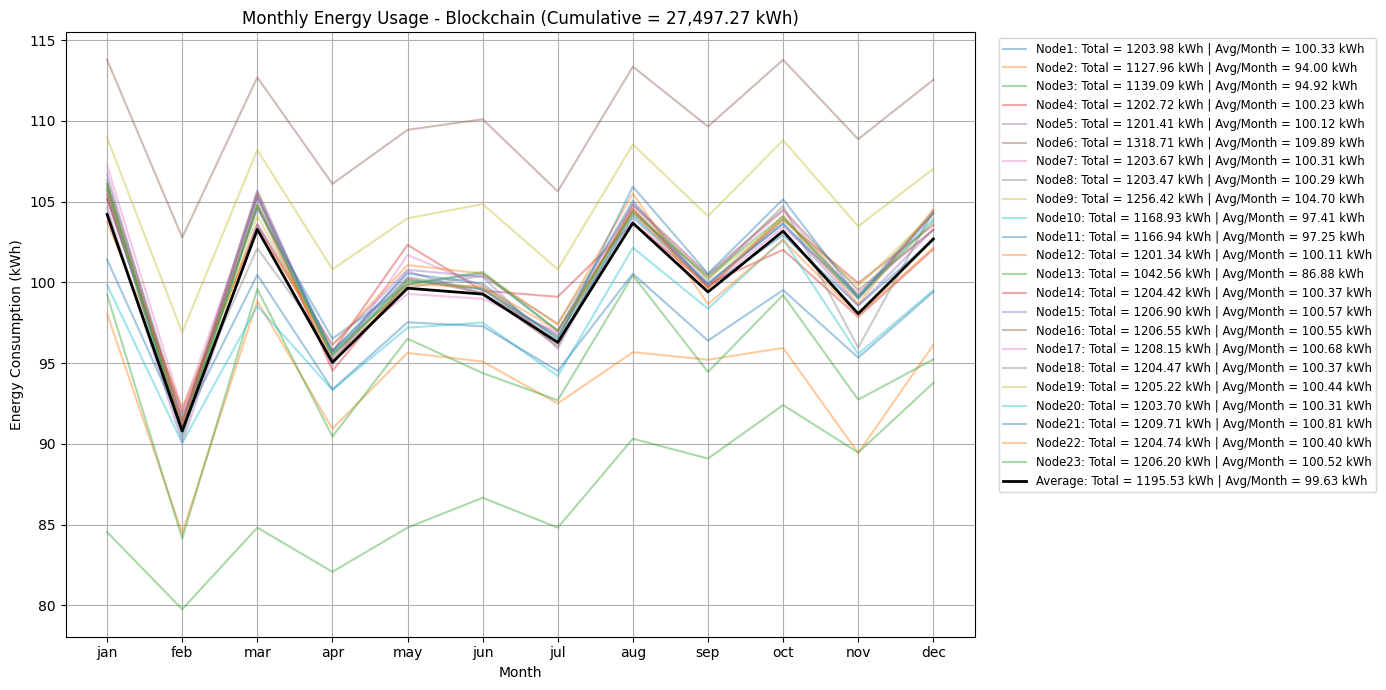

📊 Monthly line plot saved to: plots/summary/blockchain_monthly_energy_kWh_lines.png
📄 Saved cumulative energy CSV: plots/summary/blockchain_total_year_energy_kWh.csv
📄 Saved monthly total energy CSV: plots/summary/blockchain_monthly_total_energy_kWh.csv


In [40]:
plot_summary_energy_kWh(classical_path, "classical")
plot_summary_energy_kWh(blockchain_path, "blockchain")

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def compare_classical_blockchain_monthly_energy(
    classical_csv="plots/summary/classical_monthly_total_energy_kWh.csv",
    blockchain_csv="plots/summary/blockchain_monthly_total_energy_kWh.csv",
    save_path="plots/summary"
):
    os.makedirs(save_path, exist_ok=True)

    # Define month order
    month_labels = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                    'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # Load both CSVs
    df_classical = pd.read_csv(classical_csv, index_col=0)
    df_blockchain = pd.read_csv(blockchain_csv, index_col=0)

    # Drop the Yearly_Total row if present
    classical_total = df_classical.loc["Yearly_Total", "Total_kWh"] if "Yearly_Total" in df_classical.index else df_classical["Total_kWh"].sum()
    blockchain_total = df_blockchain.loc["Yearly_Total", "Total_kWh"] if "Yearly_Total" in df_blockchain.index else df_blockchain["Total_kWh"].sum()

    # Clean and reorder to months
    df_classical = df_classical.drop("Yearly_Total", errors="ignore").reindex(month_labels)
    df_blockchain = df_blockchain.drop("Yearly_Total", errors="ignore").reindex(month_labels)

    # Plot
    plt.figure(figsize=(14, 6))
    plt.plot(month_labels, df_classical["Total_kWh"], marker='o', label=f"Classical (Total = {classical_total:,.2f} kWh)")
    plt.plot(month_labels, df_blockchain["Total_kWh"], marker='s', label=f"Blockchain (Total = {blockchain_total:,.2f} kWh)")

    plt.title("Total Monthly Energy Usage: Classical vs Blockchain")
    plt.xlabel("Month")
    plt.ylabel("Total Energy (kWh)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    # Save
    plot_path = os.path.join(save_path, "comparison_monthly_energy_kWh.png")
    plt.savefig(plot_path)
    plt.show()

    # Print yearly totals
    print(f"📊 Saved comparison plot: {plot_path}")
    print(f"🔹 Classical Total Yearly Energy: {classical_total:,.2f} kWh")
    print(f"🔸 Blockchain Total Yearly Energy: {blockchain_total:,.2f} kWh")


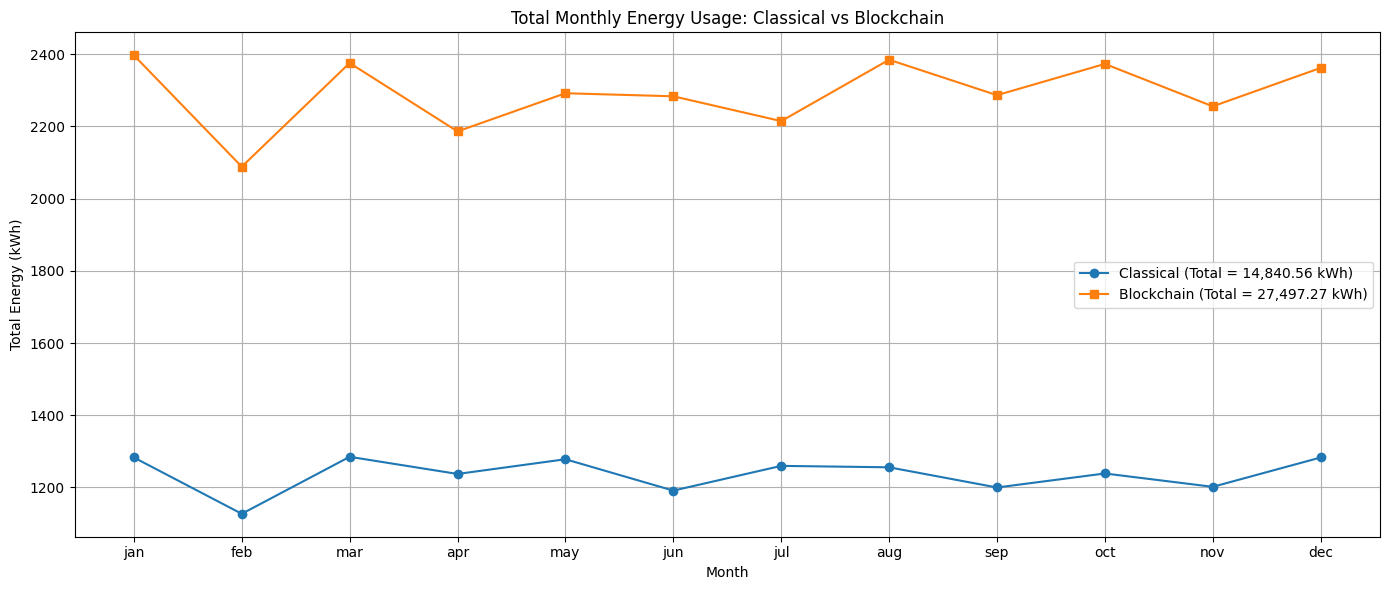

📊 Saved comparison plot: plots/summary/comparison_monthly_energy_kWh.png
🔹 Classical Total Yearly Energy: 14,840.56 kWh
🔸 Blockchain Total Yearly Energy: 27,497.27 kWh


In [44]:
compare_classical_blockchain_monthly_energy()


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def compare_classical_blockchain_monthly_energy_bar(
    classical_csv="plots/summary/classical_monthly_total_energy_kWh.csv",
    blockchain_csv="plots/summary/blockchain_monthly_total_energy_kWh.csv",
    save_path="plots/summary"
):
    os.makedirs(save_path, exist_ok=True)

    # Define month order
    month_labels = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                    'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    x = np.arange(len(month_labels))
    width = 0.35

    # Load and clean
    df_classical = pd.read_csv(classical_csv, index_col=0)
    df_blockchain = pd.read_csv(blockchain_csv, index_col=0)

    # Get totals
    classical_total = df_classical.loc["Yearly_Total", "Total_kWh"] if "Yearly_Total" in df_classical.index else df_classical["Total_kWh"].sum()
    blockchain_total = df_blockchain.loc["Yearly_Total", "Total_kWh"] if "Yearly_Total" in df_blockchain.index else df_blockchain["Total_kWh"].sum()

    # Drop Yearly_Total and reindex for plotting
    df_classical = df_classical.drop("Yearly_Total", errors="ignore").reindex(month_labels)
    df_blockchain = df_blockchain.drop("Yearly_Total", errors="ignore").reindex(month_labels)

    classical_monthly = df_classical["Total_kWh"]
    blockchain_monthly = df_blockchain["Total_kWh"]

    # Plot
    plt.figure(figsize=(14, 6))
    plt.bar(x - width/2, classical_monthly, width, label=f"Classical (Total = {classical_total:,.2f} kWh)")
    plt.bar(x + width/2, blockchain_monthly, width, label=f"Blockchain (Total = {blockchain_total:,.2f} kWh)")

    plt.xticks(x, month_labels)
    plt.ylabel("Total Energy (kWh)")
    plt.xlabel("Month")
    plt.title("Monthly Total Energy: Classical vs Blockchain")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    # Save
    plot_path = os.path.join(save_path, "comparison_monthly_energy_kWh_bar.png")
    plt.savefig(plot_path)
    plt.show()

    # Print totals
    print(f"📊 Saved bar chart: {plot_path}")
    print(f"🔹 Classical Total Yearly Energy: {classical_total:,.2f} kWh")
    print(f"🔸 Blockchain Total Yearly Energy: {blockchain_total:,.2f} kWh")

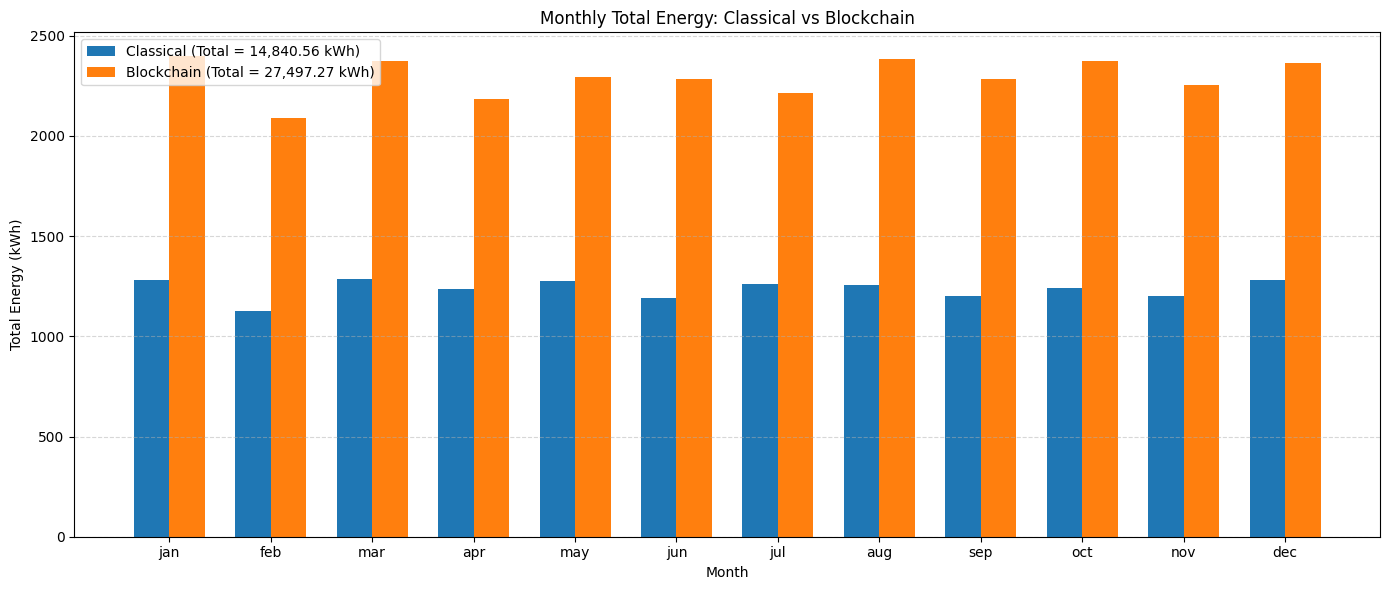

📊 Saved bar chart: plots/summary/comparison_monthly_energy_kWh_bar.png
🔹 Classical Total Yearly Energy: 14,840.56 kWh
🔸 Blockchain Total Yearly Energy: 27,497.27 kWh


In [48]:
compare_classical_blockchain_monthly_energy_bar()
